In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [6]:
with open('../../out/Estrella_full/full_dataset.filtered.Estrella_full.dat','rb') as f:
    full_dataset = pickle.load(f)
    f.close()

with open('../../out/Estrella_full/family_tags.filtered.Estrella_full.dat','rb') as f:
    family_tags = pickle.load(f)
    f.close()

means = np.mean(full_dataset,axis=0)
std = np.std(full_dataset,axis=0)
cov_data = (full_dataset-means[None,:])/std[None,:]

In [7]:
eigvals,eigvects = np.linalg.eigh(np.corrcoef(full_dataset.T))
argsort = np.argsort(eigvals)
eigvals = eigvals[argsort]
eigvects = eigvects[:,argsort]

PC1 = eigvects[:,-1]
PC2 = eigvects[:,-2]

PC1_proj = cov_data@PC1
PC2_proj = cov_data@PC2


In [9]:
def get_state(x):
    thres = 0.01
    if x[2]>thres:
        if x[4]>thres:
            state = 4
        else:
            state = 2
    elif x[3]>thres:
        if x[5]>thres:
            state = 5
        else:
            state = 3
    else:
        state = 0
    return state

color_scheme = np.array([(0,122,159), #Kp
          (90,165,202), #Km
          (255,196,69), #Alcaligenes
          (187,143,198), #pseudomonas
          (248,106,106), #Delftia
          (185,218,219), #lachnocrostidium
    ])/255

labels = ['Kp','Km','A','P','A+D','P+L']
states = [get_state(x) for x in full_dataset]


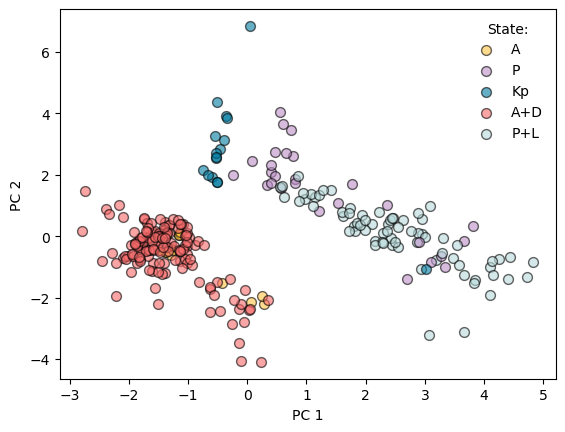

In [15]:
plotted_labels = []
fig,ax = plt.subplots()
for i,state in enumerate(states):
    ax.scatter(PC1_proj[i],
               PC2_proj[i],
               s=50,edgecolor='k',
              facecolor=color_scheme[state],alpha=0.6,
              label= labels[state] if labels[state] not in plotted_labels else None)
    plotted_labels.append(labels[state])
ax.legend(loc='best',frameon=False,title='State:')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
plt.savefig('estrela_PC1PC2_projections.png',format='png',transparent=True,dpi=300)